In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes, EfficientSU2, TwoLocal
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient, LinCombQGT, SPSAEstimatorGradient, FiniteDiffEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt
from qufold.execution_utils.measurements import _evaluate_sparsepauli
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit

In [3]:
from vqec_optimization_hkn import VQECOpt_hkn 

## VQEC workflow

In [4]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [5]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -7.28 -7.37 -7.28]
 [ 0.    0.   -7.28 -7.26]
 [ 0.    0.    0.   -7.28]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [6]:
print(qubit_op)

SparsePauliOp(['IIIIIIIII', 'IIIZZIIII', 'IIIZIZZII', 'IIIIZZZII', 'IIIIIIZZI', 'IIIZZIZZI', 'IIIZIZIZI', 'IIIIZZIZI', 'IIIIIZIIZ', 'IIIZZZIIZ', 'IIIZIIZIZ', 'IIIIZIZIZ', 'IIIIIZZZZ', 'IIIZZZZZZ', 'IIIZIIIZZ', 'IIIIZIIZZ', 'IIIIIZZII', 'IIIZZZZII', 'IIIIIIIZI', 'IIIIIIIZZ', 'IIZIIIIII', 'IIZIIIIZI', 'IIZIIIIZZ', 'IIIIIZIII', 'IIIZIZIII', 'IIIIZZIII', 'IIIZZZIII', 'IIIIIIZII', 'IIIZIIZII', 'IIIIZIZII', 'IIIZZIZII', 'IIIIIZIZI', 'IIIZZZIZI', 'IIIZIIZZI', 'IIIZIIIII', 'IIIIZIIII', 'IIIIIZIZZ', 'IIIZZZIZZ', 'IIIIIIZZZ', 'IIIZZIZZZ', 'IIIZIZZZZ', 'IIIIZZZZZ', 'IIIIZZIIZ', 'IZIIIIIII', 'IZIIIIIZI', 'IZIIIZIII', 'IZIZIZIII', 'IZIIZZIII', 'IZIZZZIII', 'IZIIIIZII', 'IZIZIIZII', 'IZIIZIZII', 'IZIZZIZII', 'IZIIIZIZI', 'IZIZIZIZI', 'IZIIZZIZI', 'IZIZZZIZI', 'IZIIIIZZI', 'IZIZIIZZI', 'IZIZZIZZI', 'IZIZIIIII', 'IZIIZIIII', 'IZIZZIIII', 'IZIIIZZII', 'IZIZIZZII', 'IZIIZZZII', 'IZIZZZZII', 'IZIIIIIZZ', 'IZIZIIIZZ', 'IZIIZIIZZ', 'IZIIIZIZZ', 'IZIZZZIZZ', 'IZIIIIZZZ', 'IZIZZIZZZ', 'IZIZIZZZZ', 'IZIIZZZZZ

In [7]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [8]:
# ansatz_ra = RealAmplitudes(qubit_op.num_qubits, skip_final_rotation_layer=False)

ansatz_su2 = EfficientSU2(qubit_op.num_qubits, skip_final_rotation_layer=False)

In [9]:
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
gradient_lincomb = LinCombEstimatorGradient(estimator=estimator)

C:\Users\8J6010897\AppData\Local\Temp\ipykernel_14716\81681451.py:1: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


[ Primal Perturb Step: 0.01, Dual Perturb Step: 0.23
Primal Perturb Step: 0.01, Dual Perturb Step: 0.78
Primal Perturb Step: 0.12, Dual Perturb Step: 0.67
Primal Perturb Step: 0.016733333333333333, Dual Perturb Step: 0.011188888888888889
Primal Perturb Step: 0.03891111111111112, Dual Perturb Step: 0.011188888888888889
Primal Perturb Step: 0.03891111111111112, Dual Perturb Step: 0.027822222222222224
Primal Perturb Step: 0.04445555555555556, Dual Perturb Step: 0.05
Primal Perturb Step: 0.05, Dual Perturb Step: 0.016733333333333333]

100%|██████████| 200/200 [03:44<00:00,  1.12s/it]
C:\Users\8J6010897\AppData\Local\Temp\ipykernel_14716\2014298526.py:40: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler(options={"shots": 10000})


Sample 0: 000110111 with probability 0.3057 and energy 5.329070518200751e-15
Sample 1: 000110110 with probability 0.1962 and energy 0.0
Sample 2: 000110101 with probability 0.0614 and energy -1.7763568394002505e-15
Sample 3: 000011010 with probability 0.0567 and energy -1.4210854715202004e-14
Sample 4: 000011011 with probability 0.0539 and energy -5.773159728050814e-15


100%|██████████| 200/200 [03:42<00:00,  1.11s/it]


Sample 0: 000111100 with probability 0.2853 and energy -1.199040866595169e-14
Sample 1: 000110111 with probability 0.2373 and energy 5.329070518200751e-15
Sample 2: 000111001 with probability 0.1054 and energy -7.105427357601002e-15
Sample 3: 000111101 with probability 0.0561 and energy -5.329070518200751e-15
Sample 4: 000111010 with probability 0.0488 and energy -4.884981308350689e-15


100%|██████████| 200/200 [03:31<00:00,  1.06s/it]


...

Sample 0: 000111010 with probability 0.1301 and energy -4.884981308350689e-15
Sample 1: 000000001 with probability 0.1123 and energy -1.7763568394002505e-14
Sample 2: 000000111 with probability 0.0862 and energy 1.7763568394002505e-15
Sample 3: 000001000 with probability 0.0741 and energy -1.7763568394002505e-15
Sample 4: 000001010 with probability 0.0739 and energy -3.552713678800501e-15


 10%|▉         | 19/200 [00:19<03:07,  1.04s/it]


Gap closed after 20 iterations; VQEC converged.
Sample 0: 111011010 with probability 0.5527 and energy -36.46999999999999
Sample 1: 011011010 with probability 0.3393 and energy -29.209999999999994
Sample 2: 111111110 with probability 0.025 and energy -21.909999999999993
Sample 3: 011111110 with probability 0.0173 and energy -14.64999999999999
Sample 4: 111111010 with probability 0.0171 and energy -7.3900000000000095


100%|██████████| 200/200 [03:09<00:00,  1.05it/s]


Sample 0: 000000101 with probability 0.132 and energy -3.552713678800501e-15
Sample 1: 000001011 with probability 0.1284 and energy 0.0
Sample 2: 000110101 with probability 0.0995 and energy -1.7763568394002505e-15
Sample 3: 000111011 with probability 0.0971 and energy -3.552713678800501e-15
Sample 4: 000000100 with probability 0.0832 and energy -1.0658141036401503e-14


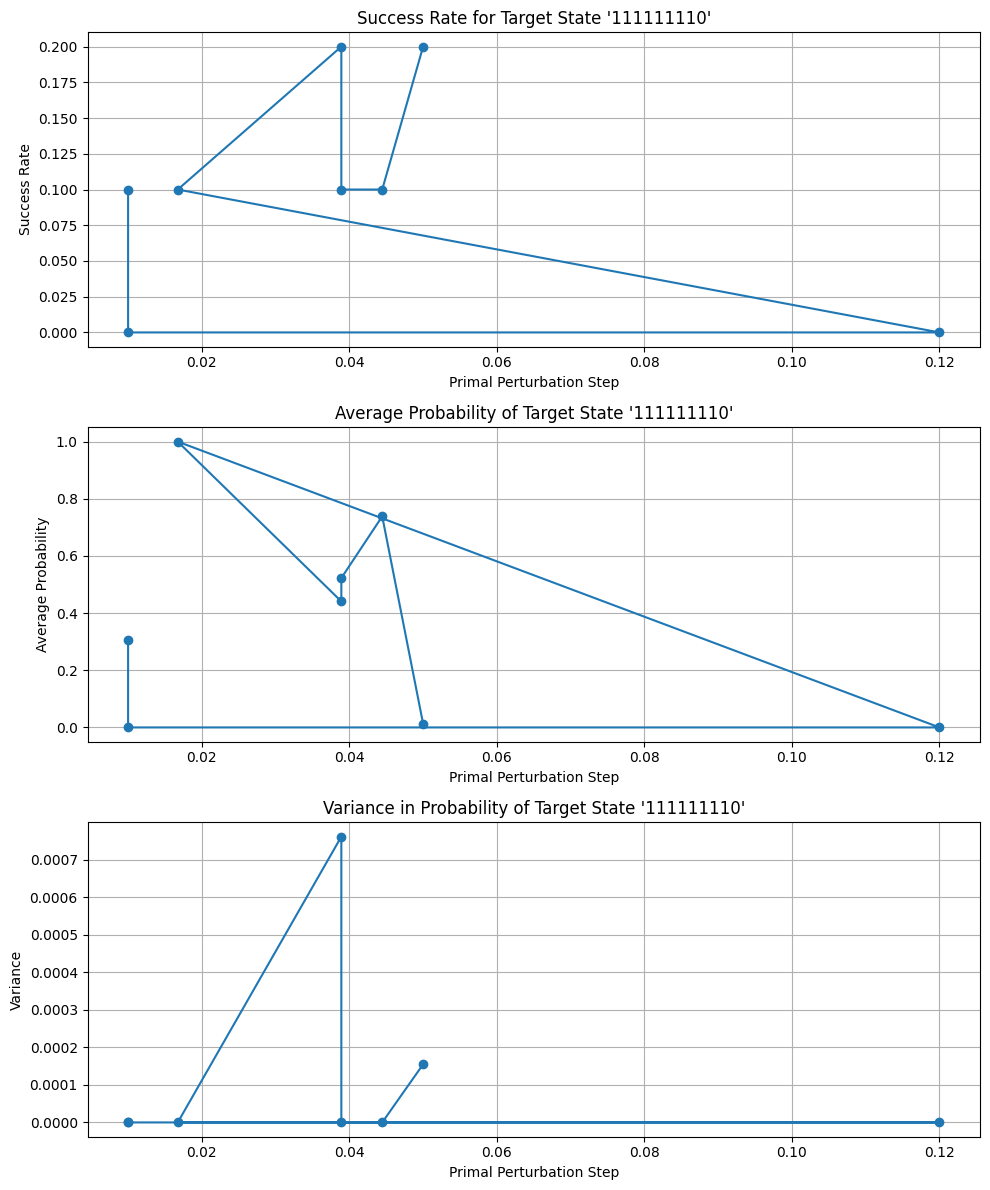

In [10]:
# List of successful completion steps
perturbation_steps = [
    (0.01, 0.23),
    (0.01, 0.78),
    (0.12, 0.67),
    (0.016733333333333333, 0.011188888888888889),
    (0.03891111111111112, 0.011188888888888889),
    (0.03891111111111112, 0.027822222222222224),
    (0.04445555555555556, 0.05),
    (0.05, 0.016733333333333333)
]

# Initialize results storage
results = []

# Iterate over each pair of primal and dual perturbation steps
for primal_step, dual_step in perturbation_steps:
    success_count = 0
    target_probabilities = []
    target_state = "111111110"

    # Run VQECOpt_hkn 10 times for each pair
    for run in range(10):
        # Run VQEC optimization with current perturbation steps
        vqec_lincomb = VQECOpt_hkn(
            primal_perturb_step=primal_step, 
            dual_perturb_step=dual_step,
            qubit_op=qubit_op, 
            constr_ops=olap_constr_ops, 
            ansatz=ansatz_su2, 
            estimator=estimator, 
            gradient=gradient_lincomb, 
            max_iter=200
        )
        vqec_lincomb_result = vqec_lincomb.optimize_primal_dual()

        # Sampling the top 5 states
        full_circ = vqec_lincomb_result.ansatz.copy()
        full_circ.measure_all()
        sampler = Sampler(options={"shots": 10000})
        sampler_result = sampler.run(
            circuits=[full_circ], 
            parameter_values=vqec_lincomb_result.optimal_primal_vars
        ).result()
        quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

        # Sort the binary strings by their probabilities
        sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))

        # Compute energies and check if target state is in top 5
        bitstring_energies = {}
        for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
            if i >= 5:
                break
            energy = _evaluate_sparsepauli(sample, qubit_op)
            bitstring_energies[sample] = energy
            print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")
            
            # Check if target state "111111110" is sampled
            if sample == target_state:
                success_count += 1
                target_probabilities.append(prob)

    # Record results for the current pair of steps
    avg_probability = np.mean(target_probabilities) if target_probabilities else 0
    variance_prob = np.var(target_probabilities) if target_probabilities else 0

    results.append({
        "primal_step": primal_step,
        "dual_step": dual_step,
        "success_rate": success_count / 10,
        "avg_probability": avg_probability,
        "variance": variance_prob
    })

# Convert results into arrays for easy plotting
primal_steps = [r["primal_step"] for r in results]
dual_steps = [r["dual_step"] for r in results]
success_rates = [r["success_rate"] for r in results]
avg_probabilities = [r["avg_probability"] for r in results]
variances = [r["variance"] for r in results]

# Plot the results
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

# Success rates plot
ax[0].plot(primal_steps, success_rates, label="Success Rate", marker="o", linestyle="-")
ax[0].set_title("Success Rate for Target State '111111110'")
ax[0].set_xlabel("Primal Perturbation Step")
ax[0].set_ylabel("Success Rate")
ax[0].grid(True)

# Average probability plot
ax[1].plot(primal_steps, avg_probabilities, label="Average Probability", marker="o", linestyle="-")
ax[1].set_title("Average Probability of Target State '111111110'")
ax[1].set_xlabel("Primal Perturbation Step")
ax[1].set_ylabel("Average Probability")
ax[1].grid(True)

# Variance plot
ax[2].plot(primal_steps, variances, label="Variance of Probability", marker="o", linestyle="-")
ax[2].set_title("Variance in Probability of Target State '111111110'")
ax[2].set_xlabel("Primal Perturbation Step")
ax[2].set_ylabel("Variance")
ax[2].grid(True)

plt.tight_layout()
plt.show()


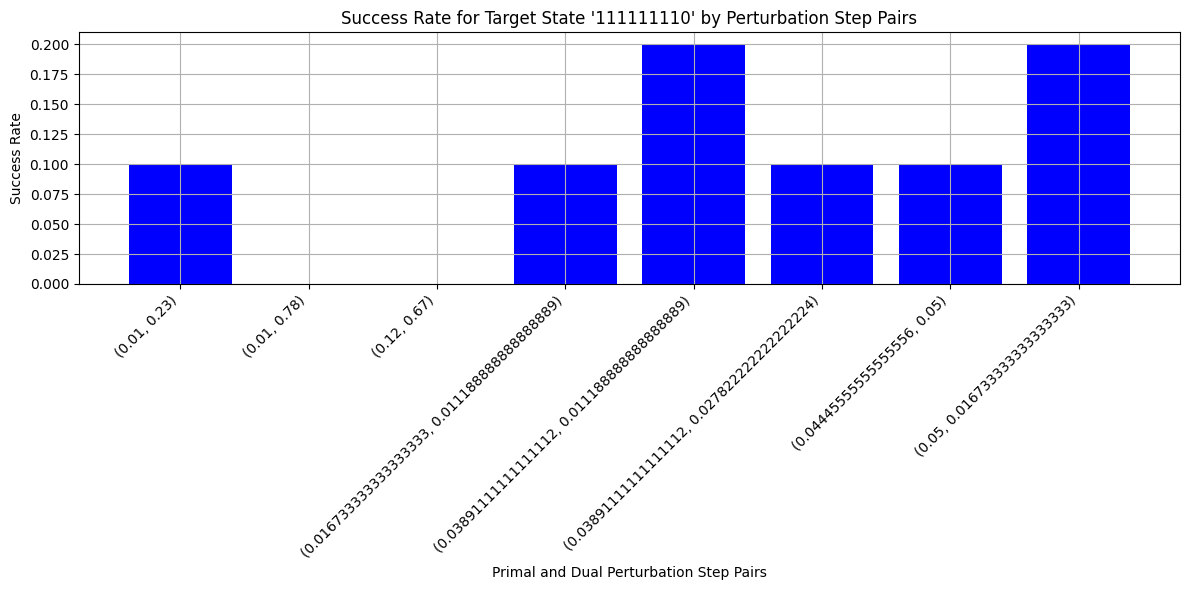

In [11]:
def plot_success_rate(results):
    """
    Plots the success rate for each pair of primal and dual perturbation steps.
    
    Args:
        results (list of dict): A list of dictionaries containing success rate information
                                for each pair of primal and dual perturbation steps.
    """
    # Create x-axis labels for each pair of perturbation steps
    step_labels = [f"({r['primal_step']}, {r['dual_step']})" for r in results]
    success_rates = [r["success_rate"] for r in results]

    # Plot the success rates
    plt.figure(figsize=(12, 6))
    plt.bar(step_labels, success_rates, color="blue")
    
    plt.title("Success Rate for Target State '111111110' by Perturbation Step Pairs")
    plt.xlabel("Primal and Dual Perturbation Step Pairs")
    plt.ylabel("Success Rate")
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# Call the function to plot success rates
plot_success_rate(results)

In [17]:
# Optimal solution for LFLF
print(_evaluate_sparsepauli("111111110", qubit_op))

print(_evaluate_sparsepauli("001001110", qubit_op))

-21.909999999999993
-7.36999999999999
